In [153]:
import pandas
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

In [154]:
datasets_path = "data"
years = [2019,2020, 2021, 2022, 2023, 2024]

df_usagers = []

for year in years:
    df_usagers_year = pandas.read_csv(os.path.join(datasets_path, str(year), f"usagers-{year}.csv"), encoding="utf-8", sep = ";")
    df_usagers.append(df_usagers_year)

df_usagers = pandas.concat(df_usagers)
df_usagers

,Num_Acc,id_vehicule,num_veh,place,catu,grav,sexe,an_nais,trajet,secu1,secu2,secu3,locp,actp,etatp,id_usager
0,201900000001,138 306 524,B01,2,2,4,2,2002.0,0,1,0,-1,-1,-1,-1,NaN
1,201900000001,138 306 524,B01,1,1,4,2,1993.0,5,1,0,-1,-1,-1,-1,NaN
2,201900000001,138 306 525,A01,1,1,1,1,1959.0,0,1,0,-1,-1,-1,-1,NaN
3,201900000002,138 306 523,A01,1,1,4,2,1994.0,0,1,0,-1,-1,-1,-1,NaN
4,201900000003,138 306 520,A01,1,1,1,1,1996.0,0,1,0,-1,-1,0,-1,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125182,202400054401,155 686 119,Y01,1,1,4,2,1978.0,0,0,0,0,-1,-1,-1,203 859 570
125183,202400054401,155 686 120,A01,1,1,1,1,1984.0,0,2,6,0,-1,-1,-1,203 859 572
125184,202400054402,155 686 118,A01,1,1,4,1,1981.0,4,1,0,-1,-1,-1,-1,203 859 569
125185,202400054402,155 686 121,B01,1,1,4,2,1986.0,9,1,0,-1,-1,-1,-1,203 859 571


In our analysis, we have decided not to use in any case these attributes: num_veh, trajet, etatp and id_usager.

In [155]:
df_usagers.drop(columns=["num_veh", "trajet", "etatp", "id_usager"] ,inplace=True)

In [156]:
df_usagers["id_vehicule"] = (
    df_usagers["id_vehicule"]
    .astype(str)
    .str.replace(r"\D", "", regex=True)  # keep only digits
    .astype("int64")
)

In [157]:
column_names_to_int = ["place", "catu", "grav", "sexe", "an_nais", "secu1", "secu2", "secu3", "locp", "actp"]

df_usagers[column_names_to_int] = df_usagers[column_names_to_int].apply(
    lambda col: pandas.to_numeric(
        col.astype(str).str.extract(r'(-?\d+)')[0],
        errors="coerce"
    )
)

In [158]:
df_usagers.replace(-1, pandas.NA, inplace=True)
df_usagers.isna().sum()

Num_Acc             0
id_vehicule         0
place              30
catu                0
grav              419
sexe            10632
an_nais         11118
secu1            9986
secu2          302741
secu3          725113
locp           341854
actp           313307
dtype: int64

Almost half of `locp` and `actp` values are missing, so let's remove these columns as well.

In [159]:
df_usagers.drop(columns=["locp", "actp"] ,inplace=True)

In [160]:
# Then we also would like to remove lines where [place, grav, sexe, an_nais] are empty.
cols_to_check = ["place", "grav", "sexe", "an_nais"]
df_usagers = df_usagers.dropna(subset=cols_to_check)

As for secu1, secu2 and secu3 these are important but we have ot convert these into more meaningfull and usable form.

For this, let's see their distribution and how they relate to gravity

In [161]:
equipments = {
    0: "aucun",
    1: "ceinture",
    2: "casque",
    3: "dispositif_enfant",
    4: "gilet_reflechissant",
    5: "airbag",
    6: "gants",
    7: "gants_airbag",
    9: "autre"
}

def encode_secu(df):
    for name in equipments.values():
        df[name] = 0

    for col in ["secu1", "secu2", "secu3"]:
        for code, name in equipments.items():
            df.loc[df[col] == code, name] = 1

    # if any equipment used → aucun = 0
    protection_cols = [c for c in equipments.values() if c != "aucun"]
    df.loc[df[protection_cols].sum(axis=1) > 0, "aucun"] = 0

    return df

df_usagers = encode_secu(df_usagers)    
df_usagers.drop(columns=["secu1", "secu2", "secu3"],inplace=True)

In [162]:
df_usagers["age"] = 2026 - df_usagers["an_nais"]
df_usagers.drop(columns="an_nais", inplace=True)

df_usagers["age_group"] = pandas.cut(
    df_usagers["age"],
    bins=[0,18,30,50,70, 100],
    labels=[0,1,2,3,4]
)

conditions = [
    df_usagers["age"] < 18,
    df_usagers["age"] < 30,
    df_usagers["age"] < 50,
    df_usagers["age"] < 70
]
choices = [0, 1, 2, 3]
df_usagers["age_group"] = np.select(conditions, choices, default=4)
df_usagers.drop(columns="age", inplace=True)

In [163]:
# On va aussi ajouter une colonne accident grave ou non pour faire une classification binaire, ca sera notre target
df_usagers["grav_bin"] = df_usagers["grav"].replace({
    1: 0,  # Non grave
    4: 0,  # Non grave
    2: 1,  # Grave
    3: 1   # Grave
})
df_usagers.drop(columns="grav", inplace=True)

In [164]:
cols_small_int = ["place", "grav_bin", "sexe", "age_group", "aucun", "ceinture", "casque", "dispositif_enfant", "gilet_reflechissant", "airbag", "gants", "gants_airbag", "autre"]
df_usagers[cols_small_int] = df_usagers[cols_small_int].astype("int64")

In [165]:
features = ['place', 'catu', 'sexe', 'age_group',
       'aucun', 'ceinture', 'casque', 'dispositif_enfant',
       'gilet_reflechissant', 'airbag', 'gants', 'gants_airbag', 'autre']

target = 'grav_bin'

In [166]:
df_usagers_analyse = df_usagers.copy()

mapping_place = {
    1: "Conducteur",
    2: "Passager avant droit",
    3: "Passager arrière droit",
    4: "Passager arrière gauche",
    5: "Passager avant gauche",
    6: "Autre place véhicule léger",
    7: "Transport en commun - place assise",
    8: "Transport en commun - debout",
    9: "Autre transport en commun",
    10: "Piéton (non applicable)"
}
df_usagers_analyse["place"] = df_usagers_analyse["place"].replace(mapping_place)

mapping = {
    1: "Conducteur",
    2: "Passager",
    3: "Piéton"
}
df_usagers_analyse["catu"] = df_usagers_analyse["catu"].replace(mapping)

mapping = {
    1: "Masculin",
    2: "Féminin"
}
df_usagers_analyse["sexe"] = df_usagers_analyse["sexe"].replace(mapping)

mapping = {
    0: "child",
    1: "young",
    2: "adult",
    3: "senior",
    4: "elderly"
}
df_usagers_analyse["age_group"] = df_usagers_analyse["age_group"].replace(mapping)

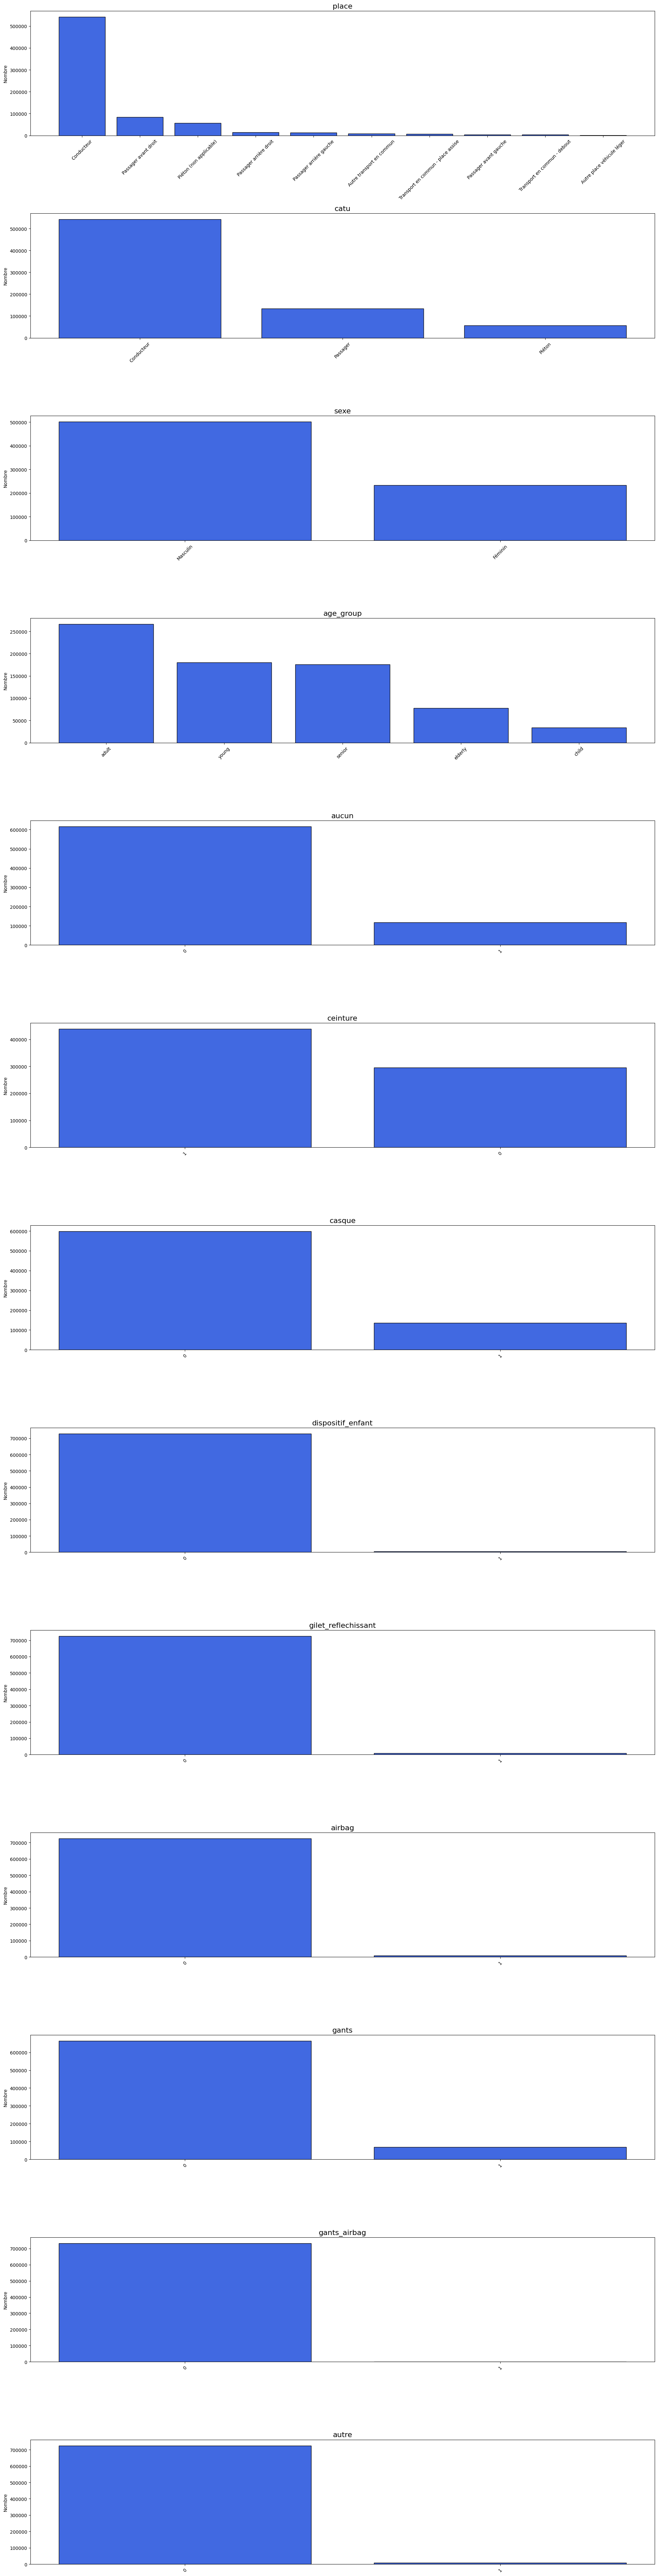

In [167]:
fig, ax = plt.subplots(len(features), 1, figsize=(20, 6*len(features)))

for i, feature in enumerate(features):
    values = df_usagers_analyse[feature]
    counts = values.value_counts()
    
    ax[i].bar(counts.index.astype(str), counts.values, color="royalblue", edgecolor="black")
    ax[i].set_title(feature, fontsize=16)
    ax[i].tick_params(axis='x', rotation=45)
    ax[i].set_ylabel("Nombre")

plt.tight_layout()

In [168]:
X = pandas.get_dummies(df_usagers[features], drop_first=True)
y = df_usagers[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, y_train)

importances = pandas.Series(model.feature_importances_, index=X.columns)
print(importances.sort_values(ascending=False))

ceinture               0.330830
age_group              0.167622
casque                 0.142084
autre                  0.089852
place                  0.072566
gants                  0.064164
aucun                  0.056273
catu                   0.029212
sexe                   0.023834
gilet_reflechissant    0.008749
dispositif_enfant      0.007195
airbag                 0.006500
gants_airbag           0.001120
dtype: float64


What it measures
Random Forest importance measures how much a feature reduces prediction error in the trees.
So it answers:
If the model could only use a few variables, which ones would it use first?
What we learn from your result
Strong predictors:
ceinture
age_group
casque
place
Moderate predictors:
gants
catu
aucun
Weak predictors:
airbag
gilet_reflechissant
dispositif_enfant
gants_airbag

In [169]:
from sklearn.feature_selection import mutual_info_classif

X = pandas.get_dummies(df_usagers[features], drop_first=True)
y = df_usagers[target]

mi = mutual_info_classif(X, y)

pandas.Series(mi, index=X.columns).sort_values(ascending=False)

ceinture               0.139421
sexe                   0.081441
catu                   0.056459
place                  0.032617
age_group              0.029923
casque                 0.025906
aucun                  0.013147
gants                  0.010923
autre                  0.005545
airbag                 0.000889
dispositif_enfant      0.000471
gilet_reflechissant    0.000112
gants_airbag           0.000103
dtype: float64

Mutual information measures:
How much knowing this variable reduces uncertainty about the target.
It detects any type of dependency, even nonlinear ones.
Unlike correlation, it works well with categorical variables.
Interpretation
If MI is close to 0, the variable is almost independent of the target.
So MI is very useful for detecting truly useless variables.

In [170]:
# We can see that both classified features ["gilet_reflechissant", "dispositif_enfant", "airbag", "gants_airbag"] 
# as containing very few information to predict the target, so let's remove them
features_to_remove = ["gilet_reflechissant", "dispositif_enfant", "airbag", "gants_airbag"]
df_usagers.drop(columns=features_to_remove, inplace=True)
features = list(set(features) - set(features_to_remove))

In [171]:
features

['ceinture',
 'catu',
 'aucun',
 'place',
 'age_group',
 'sexe',
 'gants',
 'casque',
 'autre']

In [172]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

X = pandas.get_dummies(df_usagers[features], drop_first=True)
y = df_usagers[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "Gradient Boosting": GradientBoostingClassifier()
}

for name, model in models.items():
    model.fit(X_train, y_train)

In [173]:
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

for name, model in models.items():

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:,1]

    print("\n", name)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))


 Logistic Regression
Accuracy: 0.820222882210294
              precision    recall  f1-score   support

           0       0.82      1.00      0.90    119952
           1       0.66      0.03      0.07     26852

    accuracy                           0.82    146804
   macro avg       0.74      0.52      0.48    146804
weighted avg       0.79      0.82      0.75    146804


 Decision Tree
Accuracy: 0.8201138933544045
              precision    recall  f1-score   support

           0       0.83      0.99      0.90    119952
           1       0.56      0.08      0.14     26852

    accuracy                           0.82    146804
   macro avg       0.69      0.53      0.52    146804
weighted avg       0.78      0.82      0.76    146804


 Random Forest
Accuracy: 0.8200934579439252
              precision    recall  f1-score   support

           0       0.83      0.99      0.90    119952
           1       0.56      0.08      0.14     26852

    accuracy                           0.8

AUC of Logistic Regression: 0.693
AUC of Decision Tree: 0.712
AUC of Random Forest: 0.712
AUC of Gradient Boosting: 0.710


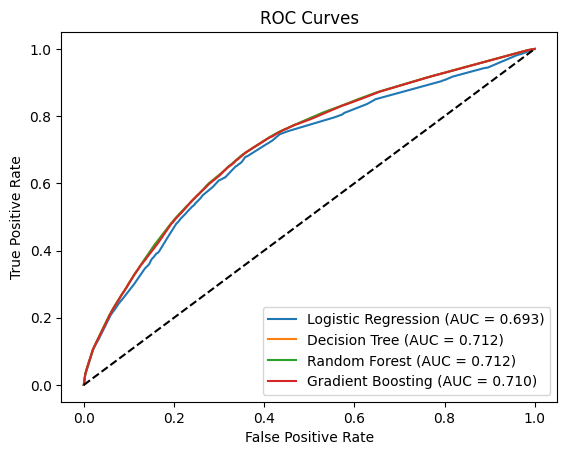

In [174]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure()

lst_auc = []

for name, model in models.items():

    y_proba = model.predict_proba(X_test)[:,1]

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_score = auc(fpr, tpr)

    lst_auc.append((name, auc_score))

    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.3f})")

    print(f"AUC of {name}: {auc_score:.3f}")

plt.plot([0,1],[0,1],"k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()

In [175]:
# Finally we are going to save the dataset cleaned
df_usagers.to_csv("df_usagers_clean.csv", index=False)

In [176]:
print("All columns:", df_usagers.columns)
print("Features:", features)
print("Target:", target)

All columns: Index(['Num_Acc', 'id_vehicule', 'place', 'catu', 'sexe', 'aucun', 'ceinture',
       'casque', 'gants', 'autre', 'age_group', 'grav_bin'],
      dtype='str')
Features: ['ceinture', 'catu', 'aucun', 'place', 'age_group', 'sexe', 'gants', 'casque', 'autre']
Target: grav_bin


In [177]:
df_usagers = pandas.read_csv("df_usagers_clean.csv")

In [178]:
df_usagers.info()

<class 'pandas.DataFrame'>
RangeIndex: 734019 entries, 0 to 734018
Data columns (total 12 columns):
 #   Column       Non-Null Count   Dtype
---  ------       --------------   -----
 0   Num_Acc      734019 non-null  int64
 1   id_vehicule  734019 non-null  int64
 2   place        734019 non-null  int64
 3   catu         734019 non-null  int64
 4   sexe         734019 non-null  int64
 5   aucun        734019 non-null  int64
 6   ceinture     734019 non-null  int64
 7   casque       734019 non-null  int64
 8   gants        734019 non-null  int64
 9   autre        734019 non-null  int64
 10  age_group    734019 non-null  int64
 11  grav_bin     734019 non-null  int64
dtypes: int64(12)
memory usage: 67.2 MB
